<a href="https://colab.research.google.com/github/scelmendorf/colab_test/blob/main/R_upload_your_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring your own dataset with R

This notebook uses **R** to load a dataset *you* upload, look at it, and make some plots.
It's built for time-series data (anything with a **date** column and a **numberic** column, like snow depth, temperature, or stream flow), but most of it works for any table.

----

To 'run' a cell, hit the ▶ play button next to each code block (or press **Shift + Enter**).

Once a cell has run you'll see a number like [1] and a green check mark ✔ appear to the left of it. Try it on the next cell.

> **First time?** Check the runtime says **R**: go to *Runtime → Change runtime type* and pick **R**. (This notebook asks for R automatically, so it should already be set.)

In [ ]:
# Load the libraries (packages) we'll use.
# Most are already installed on Colab; anything missing gets installed (this can take a minute).

pkgs <- c("readr", "readxl", "dplyr", "ggplot2", "lubridate")
missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
if (length(missing) > 0) install.packages(missing)

suppressPackageStartupMessages({
  library(readr)
  library(readxl)
  library(dplyr)
  library(ggplot2)
  library(lubridate)
})

options(repr.plot.width = 11, repr.plot.height = 5)   # make plots wide
cat("Ready to go!\n")

Ready to go!


-----
-----

# A) Upload your data and take a look

### How to upload a file
1. Click the **folder icon** 📁 in the left sidebar.
2. Click the **upload icon** (page with an up arrow) and choose your file — **.csv**, **.tsv**, **.txt**, or Excel (**.xlsx / .xls**).
3. Wait for it to appear in the file list, then run the cell below.

If you have gotten lost in the finder window on the left, you are looking for the 'content' folder to upload your file.

*No file yet? The cell will load a built-in example (monthly air temperatures in Nottingham, England, 1920–1939) so you can still try everything.*

⚠️ Uploaded files disappear when the Colab session ends, so you'll need to upload again next time.

In [ ]:
# 1. Find and read your file
data_file <- ""   # <-- optional: type a file name here, e.g. "my_data.csv"

upload_dir <- if (dir.exists("/content")) "/content" else getwd()

# define function to read any common tabular filetype
read_any <- function(path) {
  ext <- tolower(tools::file_ext(path))
  if (ext %in% c("xlsx", "xls")) {
    read_excel(path)
  } else if (ext == "tsv") {
    read_tsv(path, comment = "#", show_col_types = FALSE)
  } else if (ext == "csv") {
    # comment = "#" skips header notes like the ones in SNOTEL downloads
    read_csv(path, comment = "#", show_col_types = FALSE)
  } else {
    read_delim(path, delim = NULL, comment = "#", show_col_types = FALSE)  # guesses the separator
  }
}

if(data_file != "" && !file.exists(data_file)) {
  stop("File not found:", data_file, "\n",
  "Please upload your file to the working directory or specify a different file name.\n")
}

# alternative if no file is specified
if (data_file != "" && file.exists(data_file)) {
  raw <- read_any(data_file)
  cat("Loaded:", basename(data_file), "\n")
} else {
  raw <- tibble(Date = seq(as.Date("1920-01-01"), by = "month", length.out = length(nottem)),
                Temp_F = as.numeric(nottem))
  cat("No uploaded file found, so using the built-in example dataset.\n")
}


Loaded: HBEF_Lepidoptera_1986-2026.csv 


In [16]:
# 2. Now that you have your data, let's look at how it's formatted
cat("Rows:", nrow(raw), "  Columns:", ncol(raw), "\n\n")
glimpse(raw)
head(raw, 10)

Rows: 6129   Columns: 12 

Rows: 6,129
Columns: 12
$ Plot          <chr> "Main", "Main", "Main", "Main", "Main", "Main", "Main", "Main", "Main", "Main", "Main", "M…
$ Year          <dbl> 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, …
$ CountNumber   <dbl> 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, …
$ Date          <date> 1986-05-29, 1986-05-29, 1986-05-29, 1986-06-10, 1986-06-10, 1986-06-10, 1986-06-10, 1986-…
$ JulianDay     <dbl> 149, 149, 149, 161, 161, 161, 161, 161, 161, 175, 175, 175, 175, 175, 175, 175, 175, 175, …
$ Transect      <chr> "A", "B", "B", "A", "A", "A", "B", "D", "D", "A", "A", "A", "B", "B", "B", "C", "C", "D", …
$ GridNumber    <dbl> 6.5, 8.5, 9.5, 6.5, 8.5, 8.5, 1.5, 3.5, 10.5, 1.5, 9.5, 10.5, 2.5, 3.5, 4.5, 1.5, 10.5, 1.…
$ TreeSpecies   <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ LepTaxon      <dbl> 2, 2, 6, 6, 3, 

# A tibble: 10 × 12
   Plot   Year CountNumber Date       JulianDay Transect GridNumber TreeSpecies LepTaxon n.individuals length.mm
   <chr> <dbl>       <dbl> <date>         <dbl> <chr>         <dbl>       <dbl>    <dbl>         <dbl>     <dbl>
 1 Main   1986           1 1986-05-29       149 A               6.5           1        2             1         6
 2 Main   1986           1 1986-05-29       149 B               8.5           1        2             1         3
 3 Main   1986           1 1986-05-29       149 B               9.5           1        6             1         9
 4 Main   1986           2 1986-06-10       161 A               6.5           1        6             1         4
 5 Main   1986           2 1986-06-10       161 A               8.5           1        3             1        10
 6 Main   1986           2 1986-06-10       161 A               8.5           1        6             1         2
 7 Main   1986           2 1986-06-10       161 B               1.5         

In [15]:
# 3. A quick summary of every column (min, max, mean, missing values...)
summary(raw)

     Plot                Year       CountNumber         Date              JulianDay       Transect        
 Length:6129        Min.   :1986   Min.   :1.000   Min.   :1986-05-29   Min.   :135.0   Length:6129       
 Class :character   1st Qu.:1996   1st Qu.:2.000   1st Qu.:1996-07-11   1st Qu.:160.0   Class :character  
 Mode  :character   Median :2003   Median :3.000   Median :2003-06-30   Median :178.0   Mode  :character  
                    Mean   :2004   Mean   :2.687   Mean   :2004-10-15   Mean   :176.1                     
                    3rd Qu.:2013   3rd Qu.:4.000   3rd Qu.:2013-07-03   3rd Qu.:193.0                     
                    Max.   :2026   Max.   :4.000   Max.   :2026-07-11   Max.   :211.0                     
   GridNumber      TreeSpecies       LepTaxon        n.individuals      length.mm          biomass.mg      
 Min.   : 1.500   Min.   :1.000   Min.   :-999.000   Min.   : 1.000   Min.   :-999.000   Min.   :-999.000  
 1st Qu.: 3.500   1st Qu.:1.000   1

### Inspect:
- How many rows are in your dataset?
- What variables (columns) are included? Consult the metadata - what units are they in?
- Are there missing values (`NA`) coded in the dataset? Are they coded correctly?
- Are there missing values that are implicit (i.e. is the time series complete with all plots sampled?) How could you explore this further?

-----

## Format dates

The next section starts with some basic plots of time series. If your data don't have temporal component this might not be as useful.

In [ ]:
## 4. Choose your date format it
date_col <- "" # <-- e.g. "Date"

cols <- names(raw)

if (date_col == "") {
  stop("Please specify both a date column")
}
if (!date_col %in% cols) {
  stop("date_col isn't a column name - check spelling" = date_col %in% cols)
}

to_date <- function(x) {
  if (inherits(x, c("Date", "POSIXt"))) {
    return(as.Date(x))
  }
  as.Date(parse_date_time(as.character(x),
    orders = c("ymd", "mdy", "dmy", "ymd HMS", "ymd HM", "mdy HMS", "mdy HM", "ym", "Y"),
    quiet = TRUE
  ))
}

df <- raw %>%
  mutate(across(all_of(date_col), to_date))

head(df) 


: [1m[33mError[39m:[22m
[33m![39m Please specify both a date column and a value column.

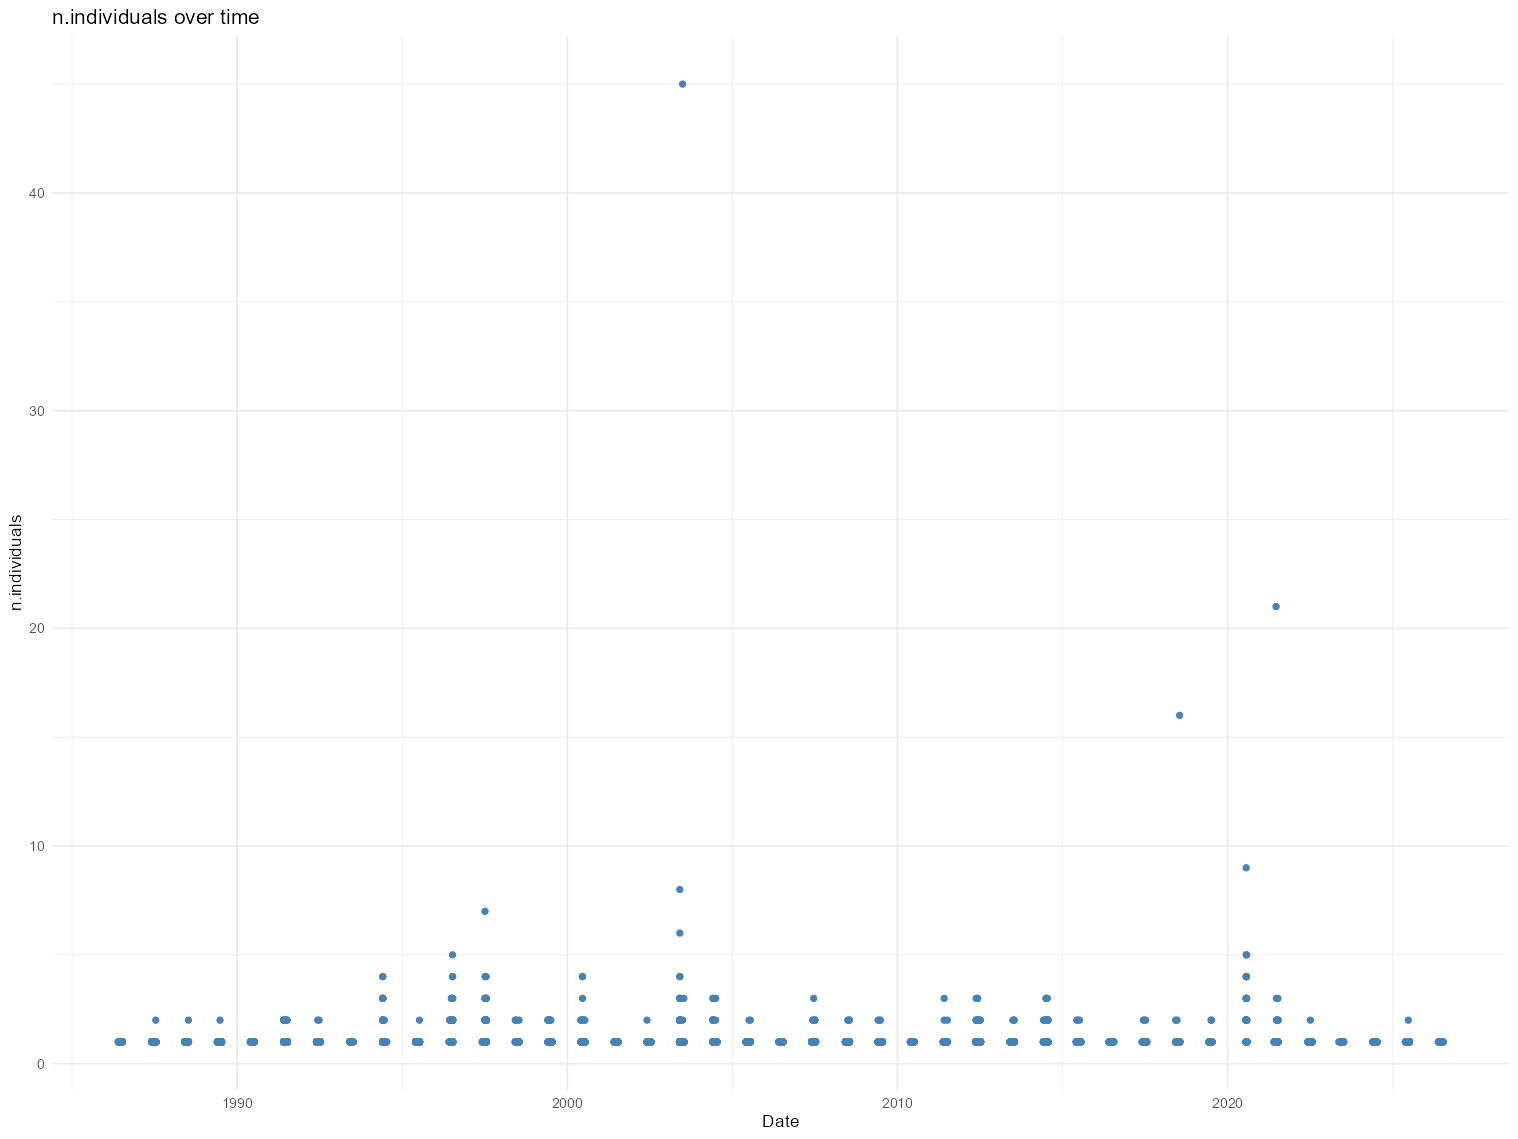

In [ ]:
# 5. Make a quick time series plot of the dataset
# chose your value column in the code below, e.g. "SWE_in"
value_col <- ""   # <-- e.g. "weight"
cols <- names(raw)
if (value_col == "") {
  stop("Please specify both a value column.")
}
if (!value_col %in% cols) {
  stop("value_col isn't a column name - check spelling" = value_col %in% cols)
}
ggplot(df, aes(x = Date, y = .data[[value_col]])) +
   geom_point(color = "steelblue") +
   labs(title = paste(value_col, "over time"), x = "Date", y = value_col) +
   theme_minimal(base_size = 14)

### Inspect:
- What do you notice about these data? Is there a repeating seasonal or annual pattern?
- Do you see gaps or odd spikes that might be errors or missing data?

----------
---------

# B) Compare years against each other

Lining every year up on the same x-axis makes it easy to see which years were unusual.

In [41]:
# 1. add a day of year and year column
df <- df %>%
  mutate(
    year          = lubridate::year(Date),
    day_of_year   = lubridate::yday(Date)
  )

# View new data frame
head(df, 10)

# A tibble: 10 × 14
   Plot   Year CountNumber Date       JulianDay Transect GridNumber TreeSpecies LepTaxon n.individuals length.mm
   <chr> <dbl>       <dbl> <date>         <dbl> <chr>         <dbl>       <dbl>    <dbl>         <dbl>     <dbl>
 1 Main   1986           1 1986-05-29       149 A               6.5           1        2             1         6
 2 Main   1986           1 1986-05-29       149 B               8.5           1        2             1         3
 3 Main   1986           1 1986-05-29       149 B               9.5           1        6             1         9
 4 Main   1986           2 1986-06-10       161 A               6.5           1        6             1         4
 5 Main   1986           2 1986-06-10       161 A               8.5           1        3             1        10
 6 Main   1986           2 1986-06-10       161 A               8.5           1        6             1         2
 7 Main   1986           2 1986-06-10       161 B               1.5         

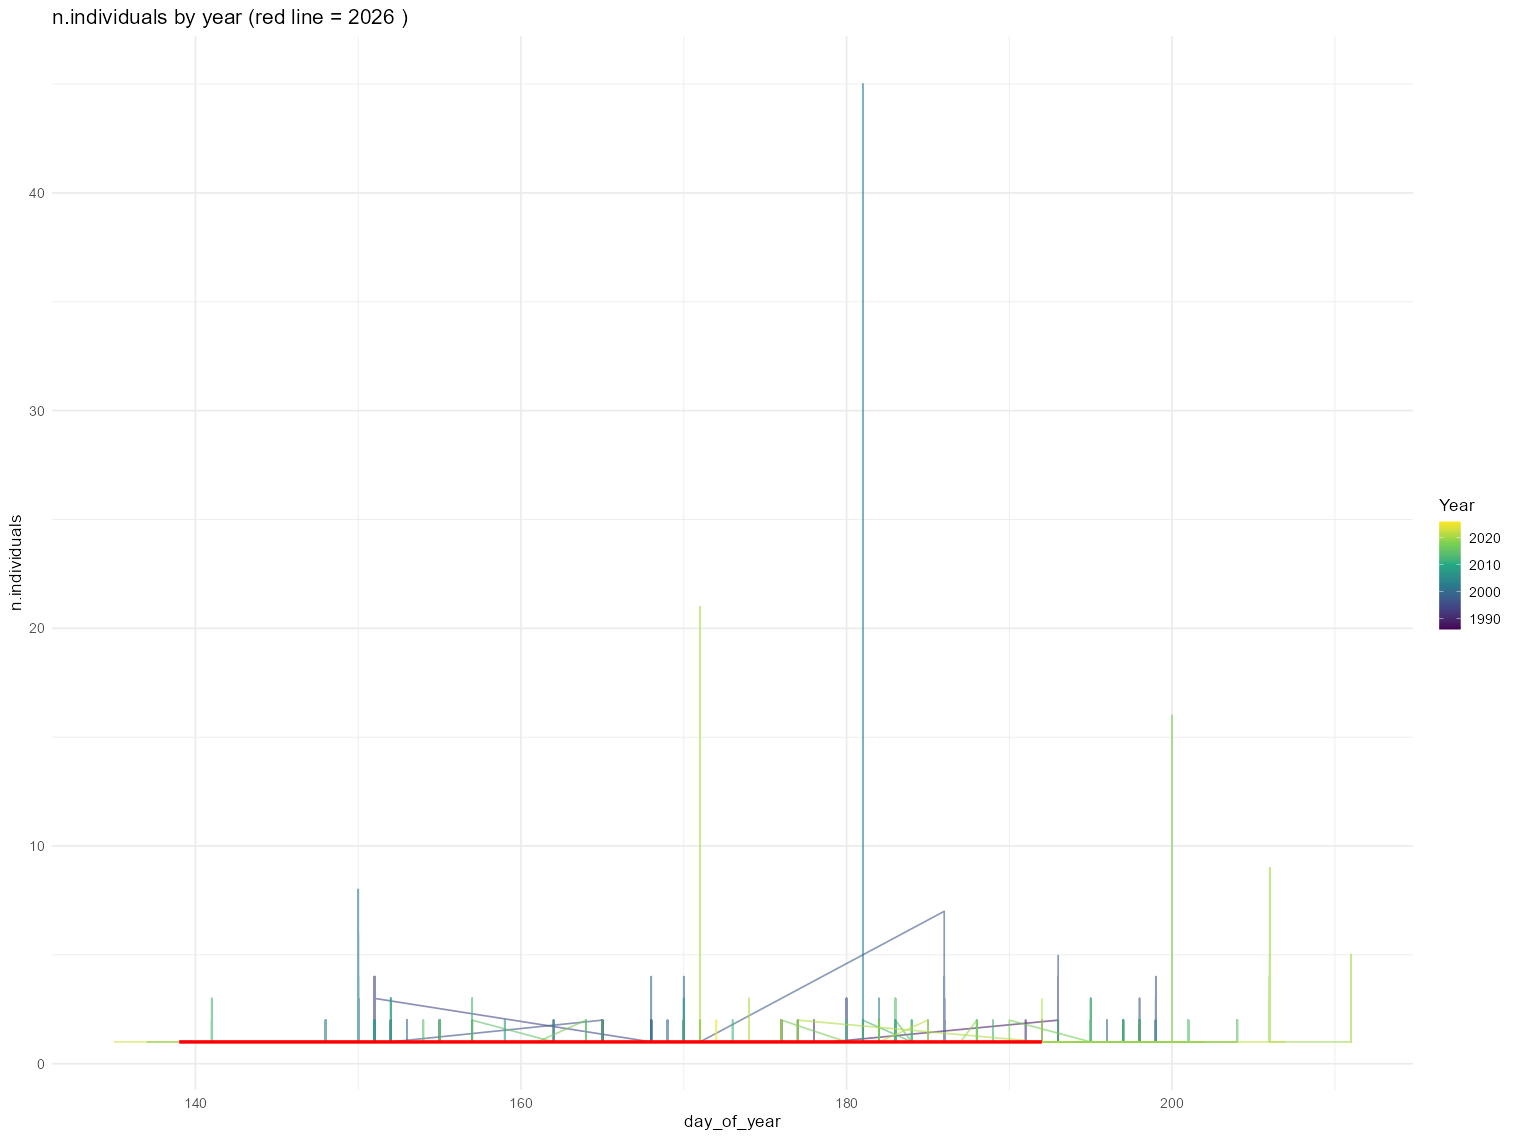

In [ ]:
# 2. Plot every year on the same axis, with the most recent year in RED
latest <- max(df$year)

time_series_plot <- ggplot(df, aes(x = day_of_year, y = .data[[value_col]], group = year)) +
  geom_line(aes(color = year), alpha = 0.6) +
  geom_line(data = filter(df, year == latest), color = "red", linewidth = 1.3) +
  scale_color_viridis_c(name = "Year") +
  labs(title = paste(value_col, "by year (red line =", latest, ")"),
       y = value_col) +
  theme_minimal(base_size = 14)

time_series_plot

### Inspect:
- How is the year-by-year plot different from the first one?
- What new information can you see from it?
- What other information would help you understand these data?


In [ ]:
# 5. (Optional) Save your plots, then download it from the 📁 file panel
# set the upload directory based on whether we're in Colab or not
upload_dir <- if (dir.exists("/content")) "/content" else getwd()
ggsave(paste0(value_col, "_time_series_plot.png"), time_series_plot, width = 10, height = 6)
cat("Saved time_series_plot.png\n")

### Your turn:
- What would you like to plot?

*See if you can start using AI to help you make new plots. Try asking for R code with `ggplot2`, and tell it a bit about your data frame and what you'd like to plot using the "generate with AI" button below to open up a Gemini coding assistant*. Remember to only upload datasets you are ok with sharing with an AI assistant!


Try your own code here:

### Adding Context:
Try uploading metadata for the dataset, asking Gemini to read the metadata and suggest additional plots.